# QDC scaling for BARRA with NatHERS

In [1]:
import xarray as xr
import os
import sys
import glob
import numpy as np
import time
from xclim import sdba
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Import utils
sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/')
import utils

# Static metadata dictionaries
from utils import locations, model_dict, vars_1hr, vars_day, cmap_dict

# sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/xsdba')
# import xsdba

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(


In [2]:
# ! python -m pip install xsdba
# import xsdba

In [3]:
##### Settings

# Narrow down SSP, RCM and start/end year
_scenario = "historical" #"ssp370" ssp126 historical
_rcm = "BARRA-R2" #"BARPA-R" #CCAM-v2203-SN"
_gcm = "ERA5"
_future = ("1990","2014") #"2041-2060"
hist_slice = "1985-2014"
obs_name = "NatHERS" #"BARRAR2
vars_subday = ['tas','huss','sfcWind','psl','clt','rsds','rsdsdir'] 
_nslots = 24
_barra_v = "BARRA-R2" # C2

timezone_dict = {"Melbourne":"Melbourne", "Darwin":"Darwin", "Cairns":"Brisbane","Brisbane":"Brisbane",
                 "Longreach":"Brisbane","Mildura":"Melbourne","Adelaide":"Adelaide","Perth":"Perth",
                 "Sydney":"Sydney","Canberra":"Canberra","Hobart":"Hobart"}

# Directories
root_dir = "/g/data/eg3/nesp_bff/"
plot_dir = "/g/data/eg3/nesp_bff/plots/qdc_adjustfactor/"
in_dir = f"{root_dir}step1_raw_data_extraction/{_rcm}/"
out_dir = f"{root_dir}step2_qdc_scaling/{_rcm}/"

import xarray as xr

def fix_duplicate_times(ds):
    """Remove duplicate time entries, keeping the first occurrence."""
    if not ds.get_index("time").is_unique:
        print(f"Found {ds.get_index('time').duplicated().sum()} duplicate time entries.")
        ds = ds.sel(time=~ds.get_index("time").duplicated())
        print("Duplicates removed.")
    else:
        print("No duplicates found.")
    return ds

def assign_to_left_bin(x, bins):
    """Assign each x to its left bin edge."""
    idx = np.digitize(x, bins, right=False) - 1  # shift to get left edge index
    idx = np.clip(idx, 0, len(bins) - 2)         # prevent overflow
    return bins[idx]
    
def plot_qdc_hourly_diagnostics_BARRA(da_obs_1hr,da_model_fut_1hr,
                                QDC_dict,adjusted,var,model,location, hour):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.gridspec as gridspec
    
    qdc = QDC_dict[hour]
    # adj = adjusted_slices[hour]
    adj = adjusted[adjusted.time.dt.hour==hour]
    
    obs_hour = da_obs_1hr.where(da_obs_1hr.time.dt.hour == hour, drop=True)
    fut_hour = da_model_fut_1hr.where(da_model_fut_1hr.time.dt.hour == hour, drop=True)
    
    # Set up GridSpec
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])
    
    ax0 = fig.add_subplot(gs[0, 0])  # Monthly means
    ax1 = fig.add_subplot(gs[0, 1])  # Heatmap
    ax2 = fig.add_subplot(gs[1, :])  # Full-width histogram
    
    fig.suptitle(f"{location}: QDC Diagnostics for {model} {var} - Hour {hour:02d} UTC", fontsize=14, y=0.95)
    
    # 1a. Monthly means
    obs_hour.groupby("time.month").mean().plot(ax=ax0, label="BARRA-R2", color="blue")
    fut_hour.groupby("time.month").mean().plot(ax=ax0, label="NatHERS", color="red")
    adj.groupby("time.month").mean().plot(ax=ax0, label="BARRA-R2 adjusted", linestyle="--", color="purple")
    ax0.set_title("Monthly Mean by Hour")
    ax0.legend()
    
    # 1b. Adjustment factor heatmap
    af = qdc.ds.af
    vmin, vmax = float(af.min()), float(af.max())
    if vmin < 0 and vmax > 0:
        cmap = "RdBu_r"
        center = 0.0
    else:
        cmap = "viridis"
        center = None
    
    af.transpose("month", "quantiles").plot.pcolormesh(
            ax=ax1, cmap=cmap, center=center,
            x="quantiles", y="month",
            cbar_kwargs={"label": "Adjustment Factor"}
    )
    ax1.set_title("QDC Adjustment Factors")
    
    # 2. Histogram
    sns.histplot(obs_hour.values.flatten(), ax=ax2, label="BARRA-R2", kde=True, stat="density", bins=50, color="blue")
    sns.histplot(fut_hour.values.flatten(), ax=ax2, label="NatHERS", kde=True, stat="density", bins=50, color="red")
    sns.histplot(adj.values.flatten(), ax=ax2, label="BARRA-R2 adjusted", kde=True, stat="density", bins=50, color="purple")
    ax2.set_title("Distributions")
    ax2.legend()
    

## QDC hourly data

---------- BARRA-R2 for hourly data ----------
========================== Melbourne =======================
***** ERA5 *****
Processing: /g/data/eg3/nesp_bff/step2_qdc_scaling/BARRA-R2/Melbourne_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_1990-2014_QDC-NatHERS_TESTclt.nc.....
Found 25 duplicate time entries.
Duplicates removed.
No duplicates found.
===== Var: tas =====
Detected hourly data → using 24 slots.
===== Var: huss =====
Detected hourly data → using 24 slots.
===== Var: sfcWind =====
Detected hourly data → using 24 slots.
===== Var: psl =====
Convert to station level pressure..
Detected hourly data → using 24 slots.
===== Var: clt =====
Adjust and bin cloud area fraction..
Detected hourly data → using 24 slots.


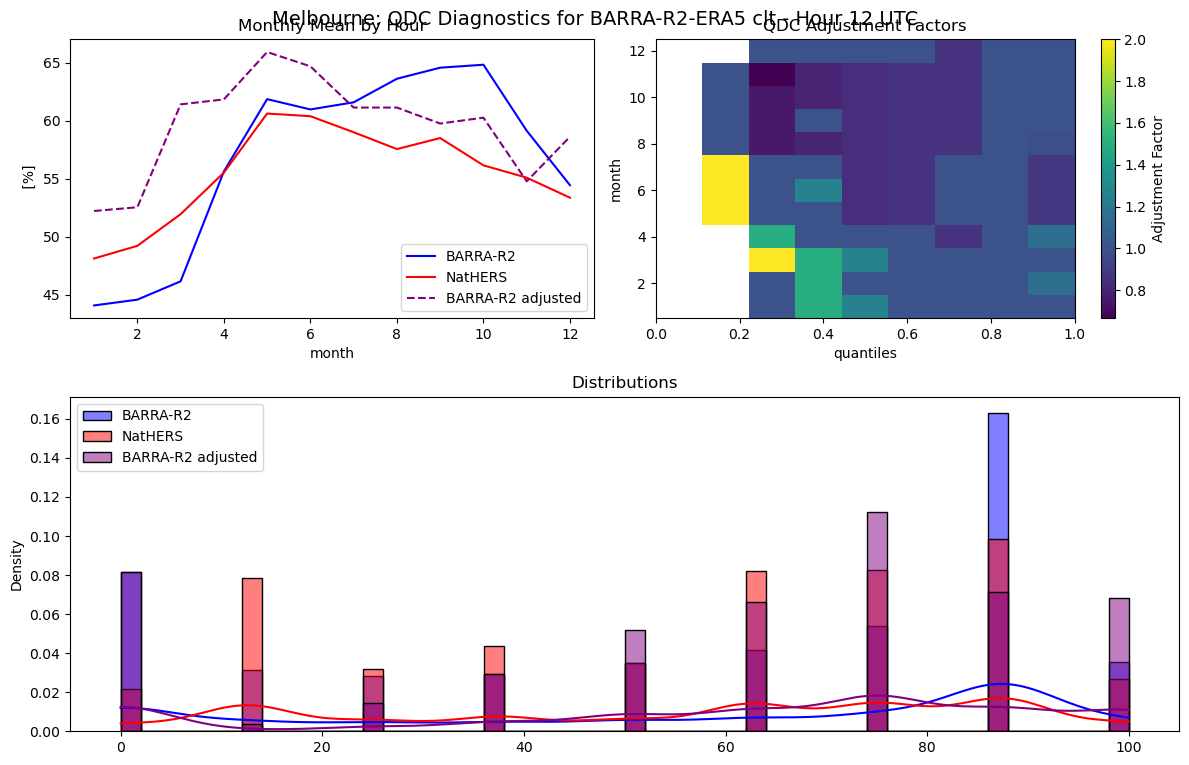

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -37.62
    lon           float64 8B 144.8
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 293.3 292.9 293.1 ... 291.9 294.3 293.7
    huss          (time) float64 2MB 0.007387 0.007135 ... 0.006341 0.007258
    sfcWind       (time) float64 2MB 7.076 7.056 7.679 ... 1.379 4.929 4.665
    psl           (time) float64 2MB 1.004e+05 1.004e+05 ... 9.997e+04 1.001e+05
    clt           (time) float64 2MB 75.0 0.0 0.0 0.0 ... 100.0 87.5 87.5 87.5
    rsds          (time) float64 2MB 308.5 453.4 1.101e+03 ... 422.3 589.8 718.2
    rsdsdir       (time) float64 2MB 15.43 47.94 958.0 ... 516.9 

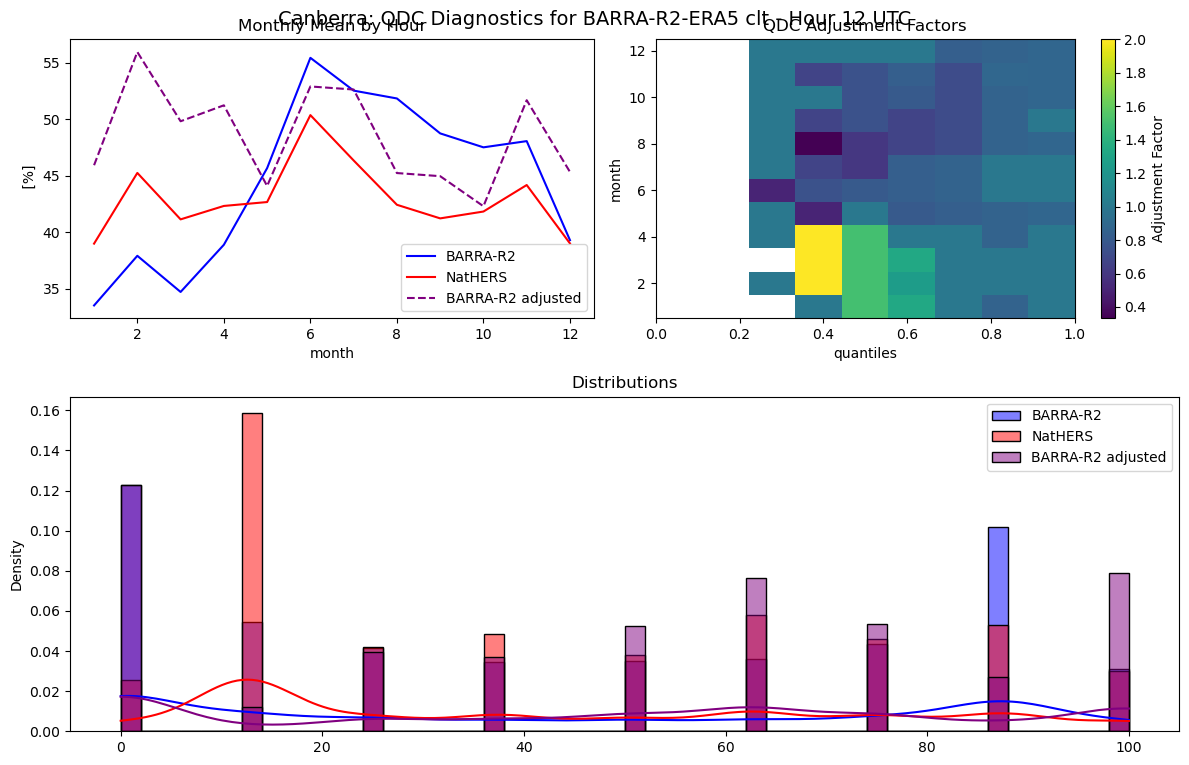

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -35.31
    lon           float64 8B 149.2
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 306.1 307.6 308.4 ... 292.3 295.2 298.2
    huss          (time) float64 2MB 0.007849 0.006487 ... 0.01098 0.009997
    sfcWind       (time) float64 2MB 5.906 7.758 8.623 8.637 ... 0.0 2.186 3.026
    psl           (time) float64 2MB 9.453e+04 9.448e+04 ... 9.468e+04 9.458e+04
    clt           (time) float64 2MB 0.0 100.0 0.0 100.0 ... 0.0 0.0 0.0 0.0
    rsds          (time) float64 2MB 1.006e+03 1.037e+03 837.9 ... 784.7 932.9
    rsdsdir       (time) float64 2MB 965.5 979.0 868.5 ... 863.3 9

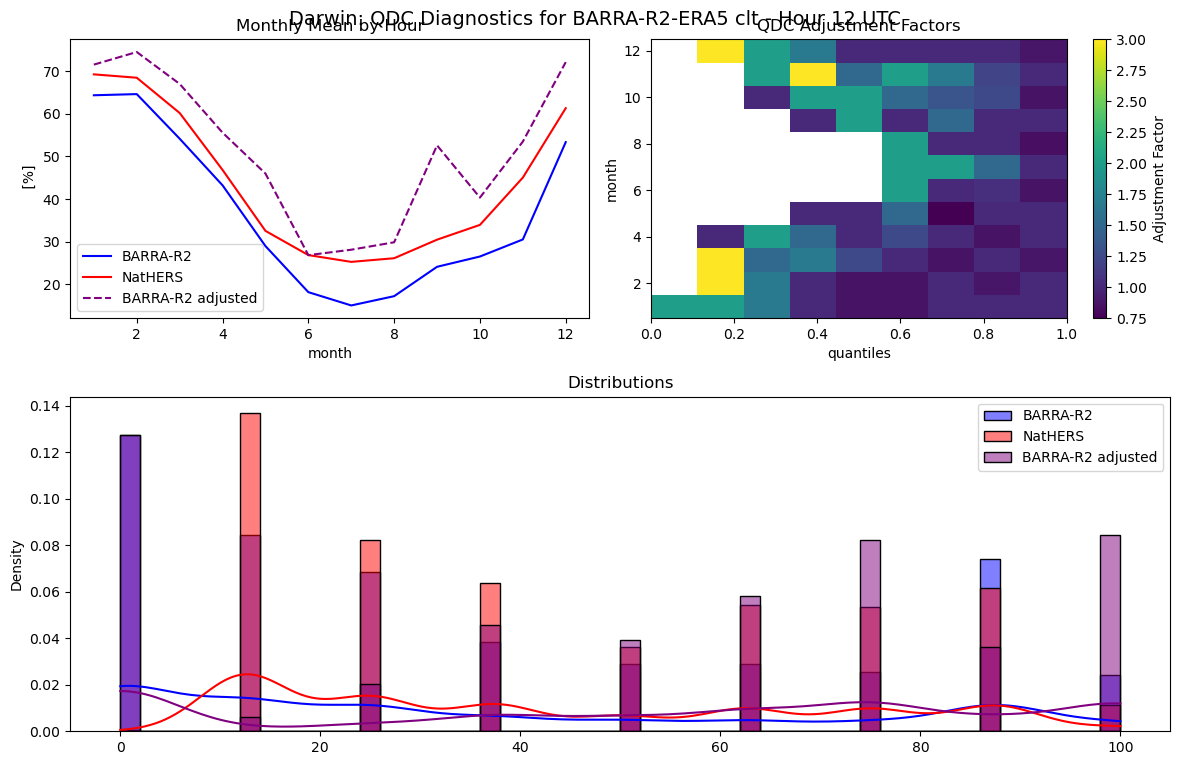

===== Var: rsds =====
Detected half-hourly data → aggregating into 24 slots.
===== Var: rsdsdir =====
Detected half-hourly data → aggregating into 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219144)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T09:30:00 ... 2015-01-0...
    lat           float64 8B -12.43
    lon           float64 8B 130.9
    crs           int32 4B 0
    time_offset   float64 8B 9.5
    round_method  <U5 20B 'floor'
Data variables:
    tas           (time) float64 2MB 304.1 305.0 306.0 ... 297.7 298.2 298.2
    huss          (time) float64 2MB 0.01612 0.01587 0.01507 ... 0.02034 0.02061
    sfcWind       (time) float64 2MB 3.369 3.744 3.235 ... 2.472 2.848 2.893
    psl           (time) float64 2MB 1.006e+05 1.006e+05 ... 1.004e+05 1.004e+05
    clt           (time) float64 2MB 75.0 62.5 62.5 75.0 ... 75.0 75.0 87.5 87.5
    rsds          (time) float64 2MB 607.9 878.4 1.019e+03 ... 0.0 27.48 92.29
    rsdsdir       (time) floa

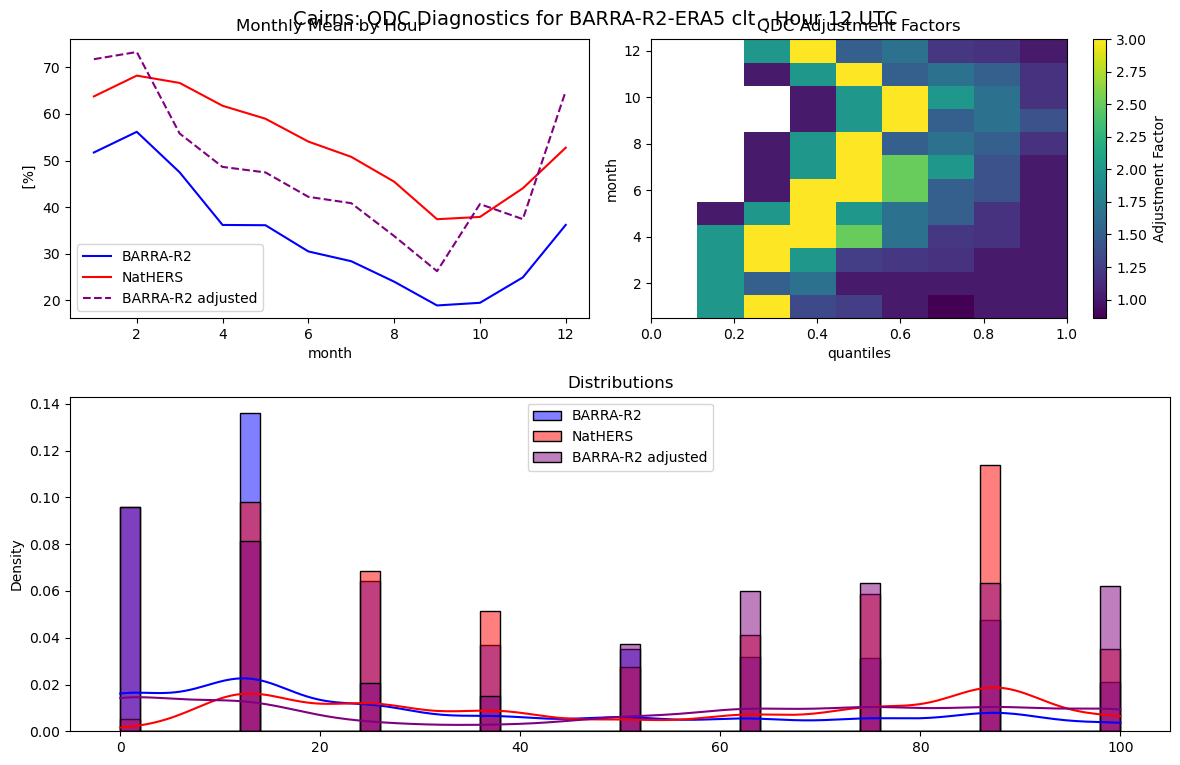

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219141)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -16.83
    lon           float64 8B 145.7
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 301.8 302.4 303.0 ... 300.1 301.8 302.8
    huss          (time) float64 2MB 0.01349 0.01305 0.01187 ... 0.01794 0.01758
    sfcWind       (time) float64 2MB 6.677 7.608 8.43 ... 2.811 3.733 3.982
    psl           (time) float64 2MB 1.011e+05 1.01e+05 ... 1.008e+05 1.008e+05
    clt           (time) float64 2MB 0.0 100.0 87.5 100.0 ... 87.5 75.0 75.0
    rsds          (time) float64 2MB 762.6 1.059e+03 877.2 ... 100.1 277.5 538.1
    rsdsdir       (time) float64 2MB 702.1 906.2 329.8 ... 64.78 

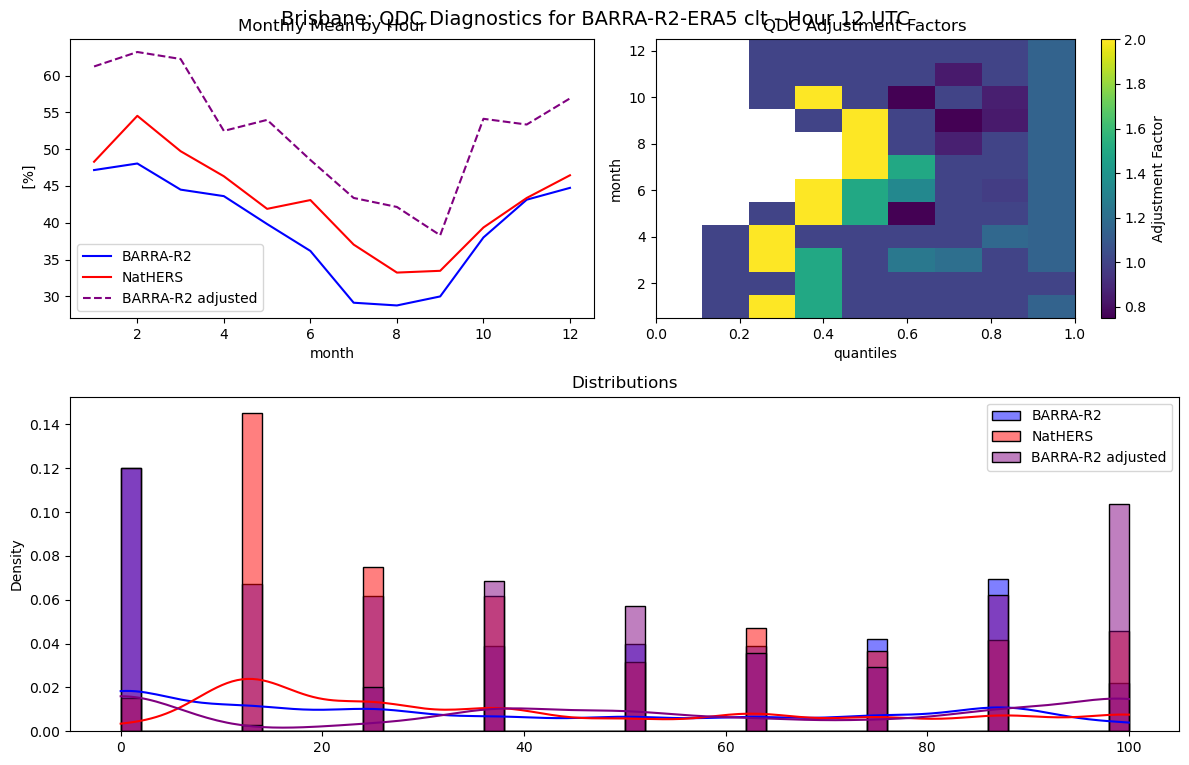

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219141)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -27.5
    lon           float64 8B 153.1
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 299.7 300.5 301.1 ... 299.2 300.1 300.6
    huss          (time) float64 2MB 0.011 0.01087 0.01078 ... 0.01677 0.01638
    sfcWind       (time) float64 2MB 4.825 5.139 6.116 ... 3.062 3.595 4.508
    psl           (time) float64 2MB 1.014e+05 1.014e+05 ... 1.013e+05 1.013e+05
    clt           (time) float64 2MB 0.0 0.0 0.0 0.0 0.0 ... 100.0 0.0 0.0 0.0
    rsds          (time) float64 2MB 1.036e+03 1.074e+03 ... 400.1 731.3
    rsdsdir       (time) float64 2MB 937.1 983.8 991.7 ... 589.9 660.8 8

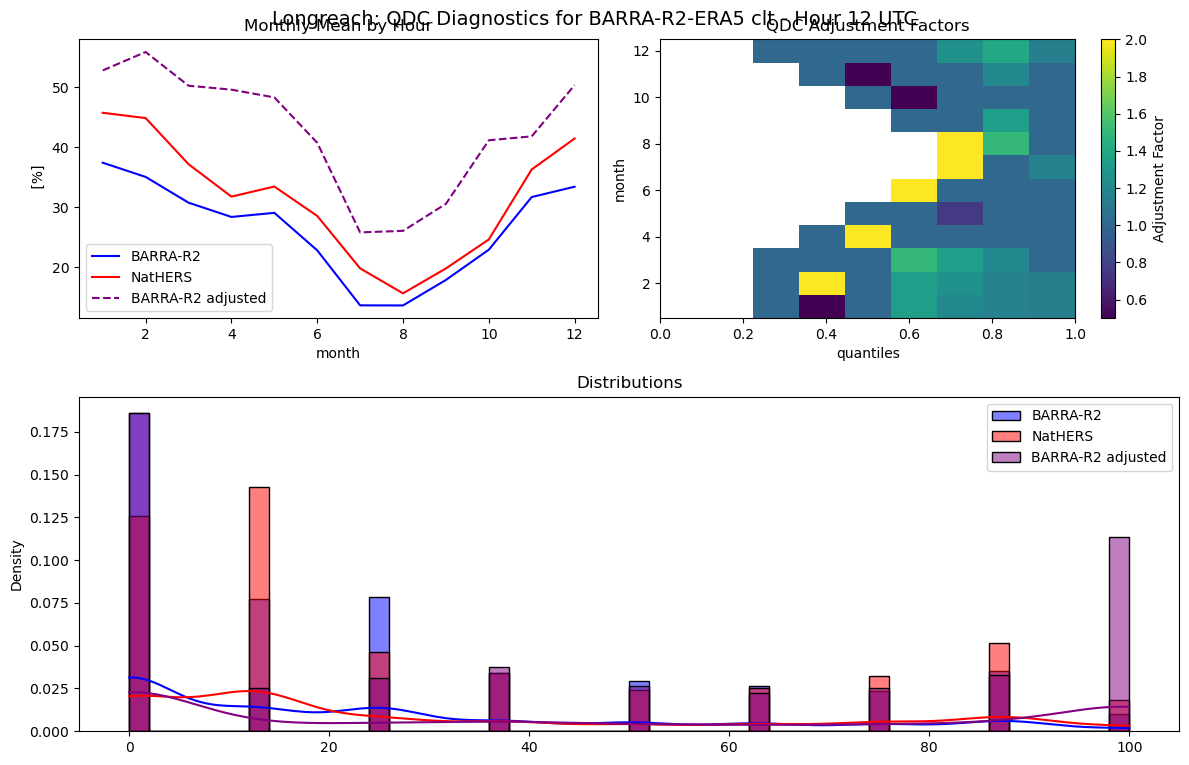

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219141)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -23.43
    lon           float64 8B 144.2
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 305.7 308.1 310.0 ... 303.4 305.5 307.7
    huss          (time) float64 2MB 0.01225 0.009305 0.006227 ... 0.0146 0.0129
    sfcWind       (time) float64 2MB 5.736 4.204 4.466 ... 6.679 7.811 8.722
    psl           (time) float64 2MB 9.92e+04 9.913e+04 ... 9.871e+04 9.877e+04
    clt           (time) float64 2MB 0.0 0.0 0.0 0.0 ... 100.0 100.0 100.0 50.0
    rsds          (time) float64 2MB 969.8 1.026e+03 1.103e+03 ... 391.5 561.1
    rsdsdir       (time) float64 2MB 936.7 911.5 991.1 ... 292.

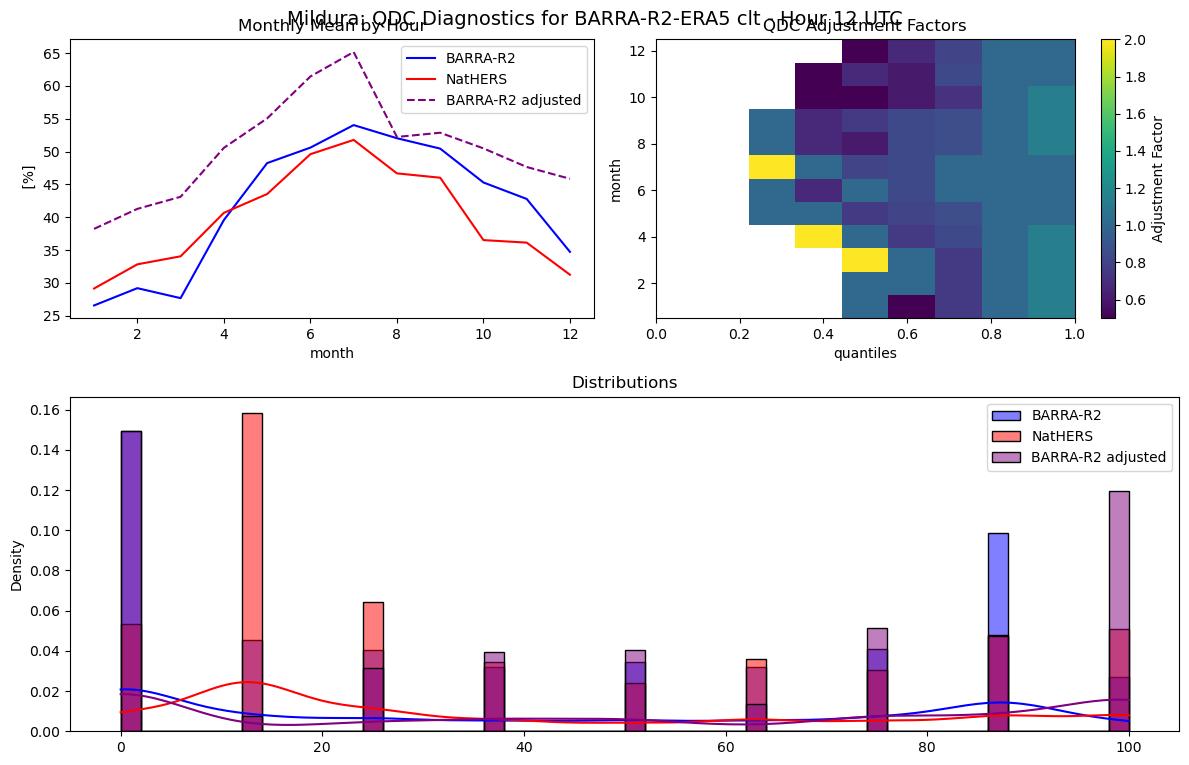

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -34.21
    lon           float64 8B 142.1
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 301.1 303.3 305.1 ... 296.3 301.0 304.8
    huss          (time) float64 2MB 0.008711 0.007714 ... 0.002541 0.002341
    sfcWind       (time) float64 2MB 4.964 4.938 4.906 ... 2.279 2.318 2.564
    psl           (time) float64 2MB 1.009e+05 1.009e+05 ... 1.006e+05 1.006e+05
    clt           (time) float64 2MB 0.0 0.0 0.0 0.0 ... 100.0 75.0 100.0 87.5
    rsds          (time) float64 2MB 960.6 1.022e+03 1.042e+03 ... 624.6 828.4
    rsdsdir       (time) float64 2MB 969.9 971.3 954.4 ... 726.3 79

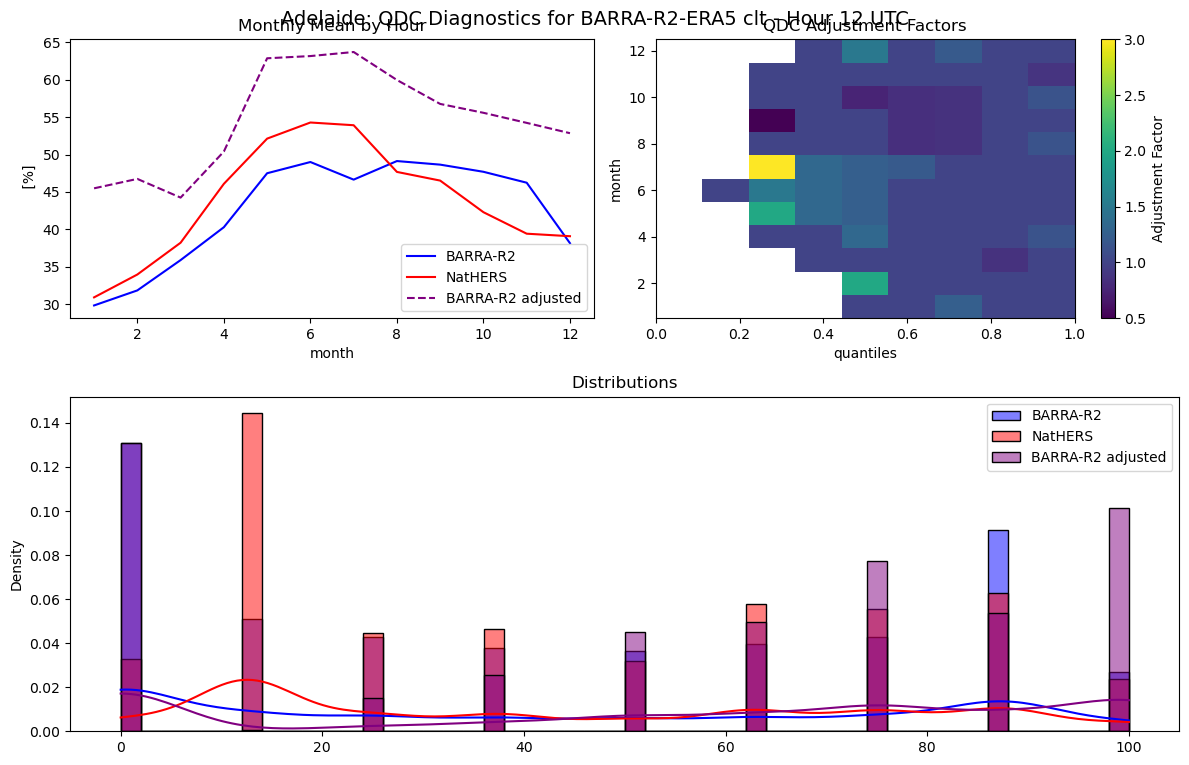

===== Var: rsds =====
Detected half-hourly data → aggregating into 24 slots.
===== Var: rsdsdir =====
Detected half-hourly data → aggregating into 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T10:30:00 ... 2015-01-0...
    lat           float64 8B -34.87
    lon           float64 8B 138.5
    crs           int32 4B 0
    time_offset   float64 8B 9.5
    round_method  <U5 20B 'floor'
Data variables:
    tas           (time) float64 2MB 299.2 300.6 301.5 ... 294.6 297.7 299.9
    huss          (time) float64 2MB 0.007458 0.006768 ... 0.006366 0.005841
    sfcWind       (time) float64 2MB 2.979 2.43 2.425 3.064 ... 0.0 2.247 2.286
    psl           (time) float64 2MB 1.011e+05 1.011e+05 ... 1.006e+05 1.005e+05
    clt           (time) float64 2MB 0.0 0.0 0.0 0.0 0.0 ... 87.5 87.5 87.5 75.0
    rsds          (time) float64 2MB 999.1 1.055e+03 1.099e+03 ... 381.6 361.1
    rsdsdir       (time) float

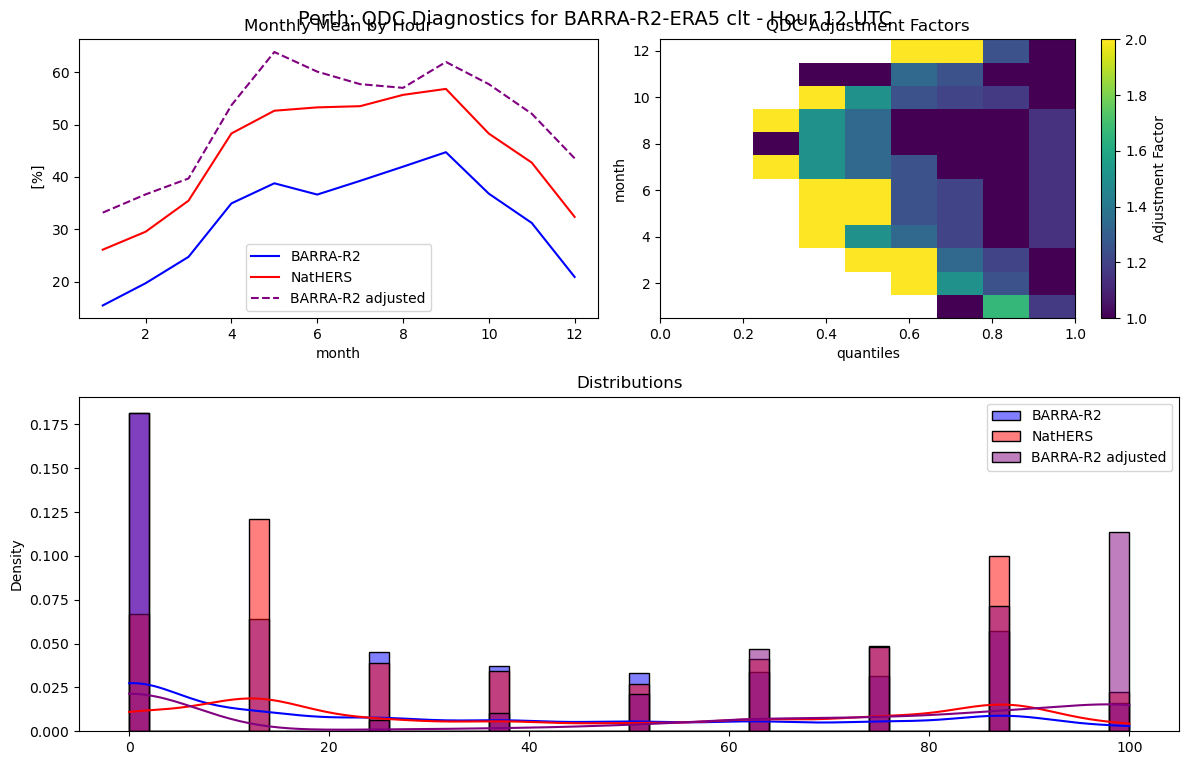

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219140)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T08:00:00 ... 2015-01-0...
    lat           float64 8B -31.9
    lon           float64 8B 115.9
    crs           int32 4B 0
    time_offset   float64 8B 8.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 291.4 293.3 294.6 ... 290.9 290.8 291.5
    huss          (time) float64 2MB 0.008168 0.008268 ... 0.008706 0.008619
    sfcWind       (time) float64 2MB 3.739 4.325 4.792 ... 3.55 3.273 4.374
    psl           (time) float64 2MB 1.01e+05 1.011e+05 ... 1.009e+05 1.009e+05
    clt           (time) float64 2MB 87.5 87.5 75.0 87.5 ... 0.0 0.0 0.0 0.0
    rsds          (time) float64 2MB 377.4 556.8 851.0 975.8 ... 0.0 140.3 340.9
    rsdsdir       (time) float64 2MB 258.2 189.1 843.0 856.4 ... 0.0 23

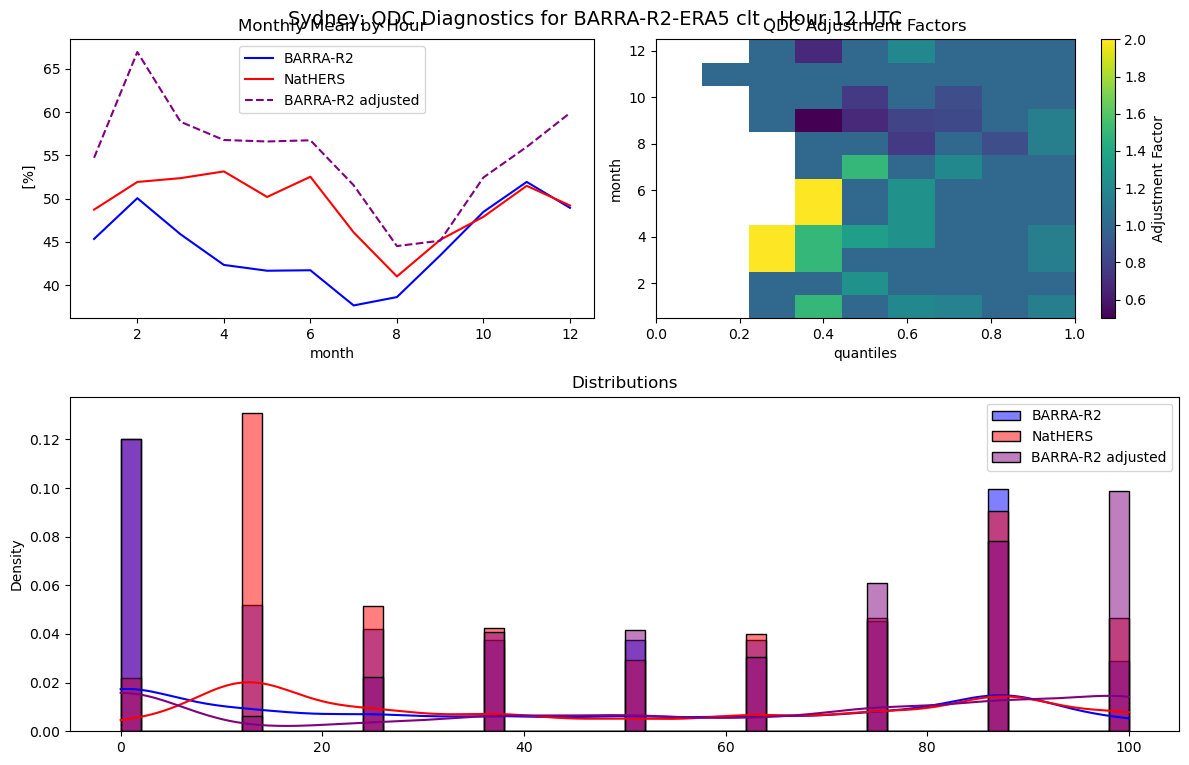

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -33.99
    lon           float64 8B 151.1
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 302.8 305.0 307.0 ... 296.9 298.2 299.2
    huss          (time) float64 2MB 0.01355 0.01305 0.01131 ... 0.01325 0.01335
    sfcWind       (time) float64 2MB 4.673 5.028 5.99 6.079 ... 3.588 5.139 5.69
    psl           (time) float64 2MB 1.012e+05 1.012e+05 ... 1.014e+05 1.014e+05
    clt           (time) float64 2MB 0.0 0.0 0.0 25.0 25.0 ... 0.0 0.0 100.0 0.0
    rsds          (time) float64 2MB 1.002e+03 1.047e+03 ... 576.7 879.9
    rsdsdir       (time) float64 2MB 923.5 975.8 984.3 ... 775.

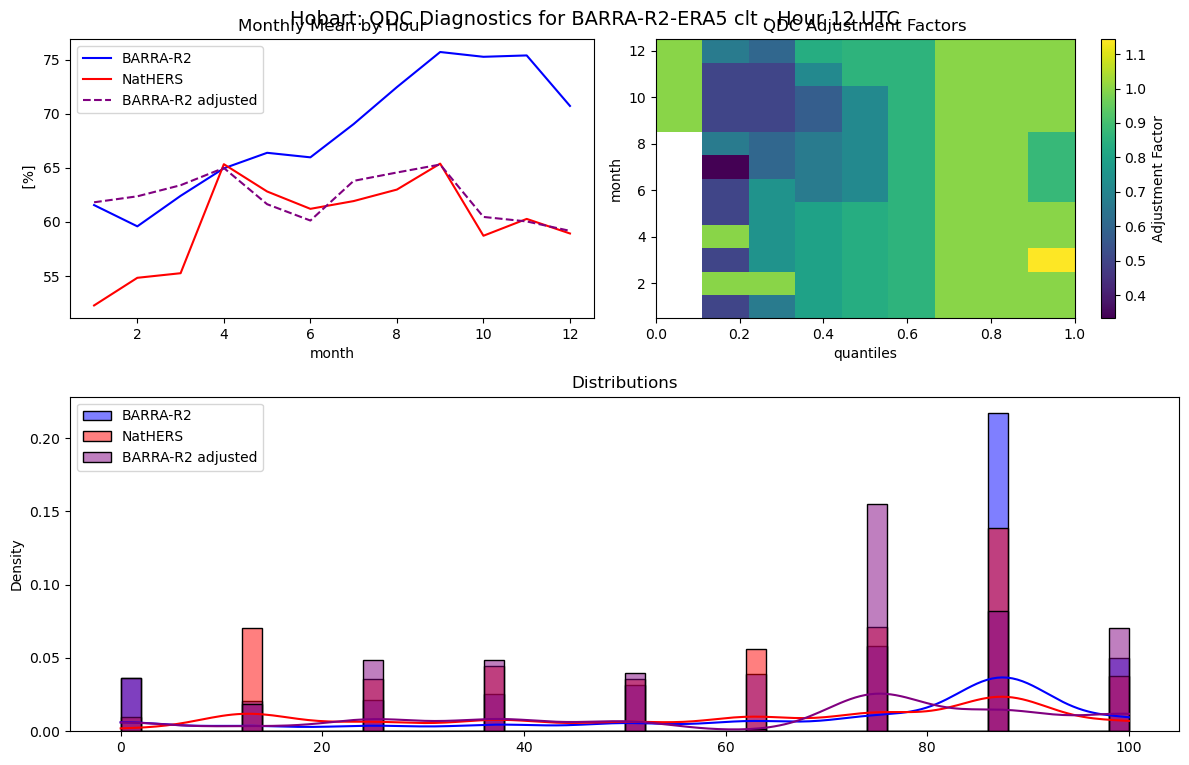

===== Var: rsds =====
Detected hourly data → using 24 slots.
===== Var: rsdsdir =====
Detected hourly data → using 24 slots.
<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -42.9
    lon           float64 8B 147.2
    crs           int32 4B 0
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
Data variables:
    tas           (time) float64 2MB 291.6 292.2 292.9 ... 291.1 292.4 293.3
    huss          (time) float64 2MB 0.0054 0.00566 ... 0.007799 0.008004
    sfcWind       (time) float64 2MB 6.371 6.333 6.565 ... 7.624 8.812 8.49
    psl           (time) float64 2MB 1.006e+05 1.006e+05 ... 1e+05 1.001e+05
    clt           (time) float64 2MB 50.0 62.5 50.0 25.0 ... 50.0 87.5 87.5 87.5
    rsds          (time) float64 2MB 591.8 932.4 773.9 ... 318.7 641.1 388.6
    rsdsdir       (time) float64 2MB 87.29 491.7 222.9 ... 298.4 482.8 62.84

In [4]:
print(f"---------- {_rcm} for hourly data ----------")
issue_list = []

for loc in locations:
    print(f"========================== {loc} =======================")
    if loc == "Thredbo":
        continue
    print(f"***** {_gcm} *****")

    out_file = (
        f"{out_dir}{loc}_"
        f"{model_dict[_rcm]['grid']}_"
        f"{_gcm}_{_scenario}_"
        f"{model_dict[_rcm]['gcms'][_gcm]['mdl_run']}_"
        f"{model_dict[_rcm]['org']}_"
        f"{_rcm}_{model_dict[_rcm]['gcms'][_gcm]['version']}_"
        f"1hr_{_future[0]}-{_future[1]}_QDC-{obs_name}_TESTclt.nc"
    )

    if not os.path.exists(out_file):
        print(f"Processing: {out_file}.....")
        
        ds_barra = xr.open_dataset(f"{root_dir}step1_raw_data_extraction/{_barra_v}/{loc}_AUS-11_ERA5_historical_hres_BOM_{_barra_v}_v1_1hr_1985-2014.nc").sel(time=slice("1990","2014")).load()
        ds_nathers = xr.open_dataset(glob.glob(f"{root_dir}/NatHERS/raw_data/{loc}_*_NatHERS_1990-2015.nc")[0]).load()

        # psl_station = utils.convert_sea_level_pressure_to_station_pressure(ds_barra.psl, locations[loc]['Elev'])

        # Convert to local time
        barra_time_utc = pd.to_datetime(ds_barra.time.values).tz_localize('UTC')
        barra_time_utc_to_local = barra_time_utc.tz_convert(f'Australia/{timezone_dict[loc]}').tz_localize(None)
        ds_barra_local = ds_barra.copy()
        ds_barra_local = ds_barra_local.assign_coords(time=barra_time_utc_to_local)
        
        offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
        ds_nathers_local = ds_nathers.copy()
        ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)
        # ds_nathers_local.coords["time_offset"] = 0

        # Apply  duplicate time check to both datasets
        ds_barra_local = fix_duplicate_times(ds_barra_local)
        ds_nathers_local = fix_duplicate_times(ds_nathers_local)

        ds_nathers_local["lat"] = ds_barra_local["lat"]
        ds_nathers_local["lon"] = ds_barra_local["lon"]
        ds_barra_local, ds_nathers_local = xr.align(ds_barra_local, ds_nathers_local, join="inner")

        # print(ds_barra_local,"\n",ds_nathers_local)

        facet_data = []
        var_list = []

        
        for _var in vars_subday:
            print(f"===== Var: {_var} =====")
            _nq=100

            if _var == 'psl':
                print("Convert to station level pressure..")
                ds_barra_local = ds_barra_local.assign(psl=utils.convert_sea_level_pressure_to_station_pressure(
                                ds_barra_local.psl, locations[loc]["Elev"]))

            if _var == 'clt':
                print("Adjust and bin cloud area fraction..")
                # Clip to valid range
                ds_nathers_local = ds_nathers_local.assign(clt=ds_nathers_local.clt.clip(0,100))
                barra_clt_clip = ds_barra_local.clt.clip(0, 100)

                bins = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100., 112.5])
                _nq = 9
                
                # Apply bins
                barra_clt_binned = xr.apply_ufunc(
                    assign_to_left_bin,
                    barra_clt_clip,
                    kwargs={"bins": bins},
                    vectorize=True,
                    dask="parallelized",
                    output_dtypes=[float],
                    )
                ds_barra_local = ds_barra_local.assign(clt=barra_clt_binned)
                ds_barra_local.clt.attrs["units"] = barra_clt_clip.attrs["units"]
                
            da_obs = ds_barra_local[_var]
            da_model_hist = ds_barra_local[_var]
            da_model_fut = ds_nathers_local[_var]

            _kind = '+' if _var in ["tas"] else '*'
                            
            da_adjusted, QDC_dict, adjusted_slices = utils.apply_qdc_sliding_window(
                da_obs=da_obs,
                da_model_historical=da_model_hist,
                da_model_future=da_model_fut,
                var=_var,
                nq = _nq,
                kind=_kind,
                window=1,
                nslots=_nslots
            )

            if _var == 'clt':# Apply with vectorization and dask support
                da_adjusted_bin = xr.apply_ufunc(
                    assign_to_left_bin,
                    da_adjusted,
                    kwargs={"bins": bins},
                    vectorize=True,
                    dask="parallelized",
                    output_dtypes=[float],
                    )
                da_adjusted = da_adjusted_bin
                da_adjusted.attrs["units"] = barra_clt_clip.attrs["units"]
            
            var_list.append(da_adjusted.rename(_var).to_dataset())

            # Plotting diagnostics
            selected_hours = [12] #[0,2,4,6,8,10,12,14,16,18,20,22]
            for hour in selected_hours:
                fig_file = plot_dir+(out_file.replace(".nc",f"_AdjFact_facetplot_{_var}_{hour}UTC.pdf").split('/')[-1])
                if _var in ["clt"]:
                    plot_diagnostics = plot_qdc_hourly_diagnostics_BARRA(da_obs,da_model_fut,QDC_dict,
                                                                             da_adjusted,_var,
                                                                             f"{_rcm}-{_gcm}",loc, hour)
                    plt.tight_layout()
                    # if not os.path.exists(fig_file):
                    #     plt.savefig(fig_file, bbox_inches='tight')
                    #     plt.close()
                    plt.show()
                    
        da_var = xr.merge(var_list)
        print(da_var)
        da_var.to_netcdf(out_file)
    else:
        print(f'File for {loc} exists in output directory.')
            
        # except Exception as e:
        #     issue_list.append(f"Issue with {_gcm} for {loc}. File not created: {out_file}. Error:{e}")
        #     print(f"Issue with in {_gcm}. Not creating {out_file}. Skipping to next. Error:{e}")


In [ ]:
for item in issue_list:
    print("Summary of issues and files not created because of it: \n",item,"\n")

In [ ]:
# Convert to local time
barra_time_utc = pd.to_datetime(ds_barra.time.values).tz_localize('UTC')
barra_time_utc_to_local = barra_time_utc.tz_convert(f'Australia/{loc}').tz_localize(None)
ds_barra_local = ds_barra.copy()
ds_barra_local = ds_barra_local.assign_coords(time=barra_time_utc_to_local)

offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
ds_nathers_local = ds_nathers.copy()
ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)
# ds_nathers_local.coords["time_offset"] = 0


print("NatHERS local time example:", ds_nathers_local.time[:5].values)
print("BARRA local time example:", ds_barra_local.time[:5].values)


In [ ]:
ds_barra_local

In [ ]:
ds_barra_local, ds_nathers_local = xr.align(ds_barra_local, ds_nathers_local, join="inner")

In [ ]:
print(ds_barra_local.get_index("time").duplicated().sum())
print(ds_nathers_local.get_index("time").duplicated().sum())
print(ds_barra_local.get_index("time")[ds_barra_local.get_index("time").duplicated()])

In [ ]:
ds_nathers_local.groupby("time.hour").mean().tas.plot()
ds_barra_local.groupby("time.hour").mean().tas.plot()

In [ ]:
ds_nathers_local.sel(time="'1990-03-04").tas.plot()
ds_barra_local.sel(time="'1990-03-04").tas.plot()

In [6]:
ds_barra_local.psl

<xarray.DataArray 'psl' (time: 219119)> Size: 2MB
array([100669.93729609, 100689.81564795, 100723.6088461 , ...,
        99885.73631544,  99950.34095896, 100078.55632842])
Coordinates:
  * time     (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-01T10:...
    lat      float64 8B -42.9
    lon      float64 8B 147.2
    crs      int32 4B 0
Attributes:
    long_name:      Sea Level Pressure
    standard_name:  air_pressure_at_mean_sea_level
    cell_methods:   time: point (interval: 1H)
    units:          Pa
    grid_mapping:   crs

In [25]:
loc="Canberra"
ds_barra = xr.open_dataset(f"{root_dir}step1_raw_data_extraction/{_barra_v}/{loc}_AUS-11_ERA5_historical_hres_BOM_{_barra_v}_v1_1hr_1985-2014.nc").sel(time=slice("1990","2014")).load()
ds_nathers = xr.open_dataset(glob.glob(f"{root_dir}/NatHERS/raw_data/{loc}_*_NatHERS_1990-2015.nc")[0]).load()

# psl_station = utils.convert_sea_level_pressure_to_station_pressure(ds_barra.psl, locations[loc]['Elev'])

# Convert to local time
barra_time_utc = pd.to_datetime(ds_barra.time.values).tz_localize('UTC')
barra_time_utc_to_local = barra_time_utc.tz_convert(f'Australia/{timezone_dict[loc]}').tz_localize(None)
ds_barra_local = ds_barra.copy()
ds_barra_local = ds_barra_local.assign_coords(time=barra_time_utc_to_local)

offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
ds_nathers_local = ds_nathers.copy()
ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)
# ds_nathers_local.coords["time_offset"] = 0

# Apply  duplicate time check to both datasets
ds_barra_local = fix_duplicate_times(ds_barra_local)
ds_nathers_local = fix_duplicate_times(ds_nathers_local)

ds_nathers_local["lat"] = ds_barra_local["lat"]
ds_nathers_local["lon"] = ds_barra_local["lon"]
ds_barra_local, ds_nathers_local = xr.align(ds_barra_local, ds_nathers_local, join="inner")

Found 25 duplicate time entries.
Duplicates removed.
No duplicates found.


In [26]:
locations['Canberra']['Elev']

580.0

In [27]:
(ds_nathers_local.psl-ds_barra_local.psl)

<xarray.DataArray 'psl' (time: 219119)> Size: 2MB
array([-6628., -6681., -6633., ..., -6647., -6722., -6703.])
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B -35.31
    lon           float64 8B 149.2
    time_offset   float64 8B 10.0
    round_method  float64 8B nan
    crs           int32 4B 0

In [28]:
ds_barra_local_corr = ds_barra_local.assign(psl=utils.convert_sea_level_pressure_to_station_pressure(
                                ds_barra_local.psl, locations[loc]["Elev"]))

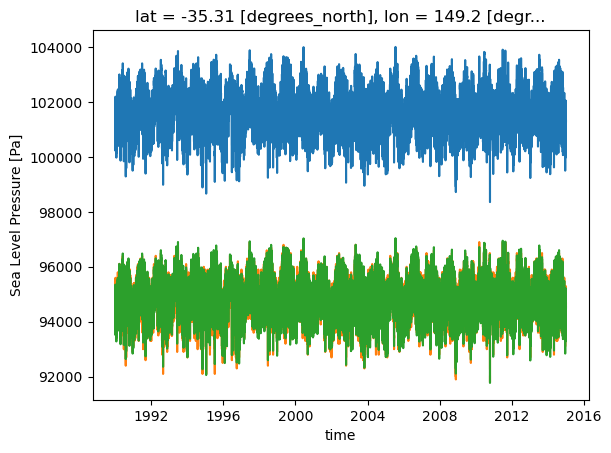

In [29]:
# (ds_nathers_local.psl-ds_barra_local.psl).plot()
ds_barra_local.psl.plot()
ds_nathers_local.psl.plot()
ds_barra_local_corr.psl.plot()

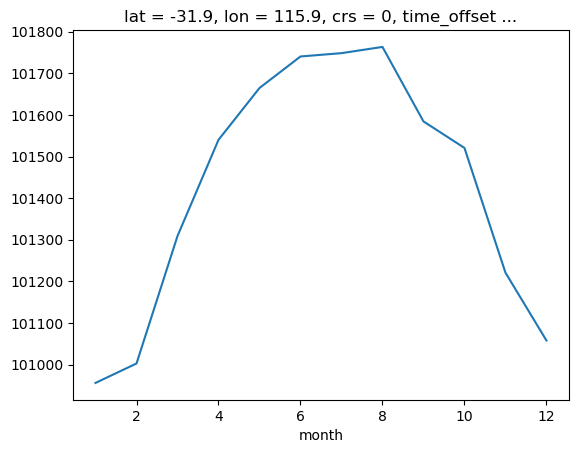

In [50]:
adj.groupby("time.month").mean().plot()

## Trying to bias adjust discrete cloud fraction with Empirical Frequency Matching

In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.stats import entropy, wasserstein_distance, chisquare

# plotting niceties
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12})


In [5]:
loc="Melbourne"
ds_barra = xr.open_dataset(f"{root_dir}step1_raw_data_extraction/{_barra_v}/{loc}_AUS-11_ERA5_historical_hres_BOM_{_barra_v}_v1_1hr_1985-2014.nc").sel(time=slice("1990","2014")).load()
ds_nathers = xr.open_dataset(glob.glob(f"{root_dir}/NatHERS/raw_data/{loc}_*_NatHERS_1990-2015.nc")[0]).load()

# psl_station = utils.convert_sea_level_pressure_to_station_pressure(ds_barra.psl, locations[loc]['Elev'])

# Convert to local time
barra_time_utc = pd.to_datetime(ds_barra.time.values).tz_localize('UTC')
barra_time_utc_to_local = barra_time_utc.tz_convert(f'Australia/{timezone_dict[loc]}').tz_localize(None)
ds_barra_local = ds_barra.copy()
ds_barra_local = ds_barra_local.assign_coords(time=barra_time_utc_to_local)

offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
ds_nathers_local = ds_nathers.copy()
ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)
# ds_nathers_local.coords["time_offset"] = 0

# Apply  duplicate time check to both datasets
ds_barra_local = fix_duplicate_times(ds_barra_local)
ds_nathers_local = fix_duplicate_times(ds_nathers_local)

ds_nathers_local["lat"] = ds_barra_local["lat"]
ds_nathers_local["lon"] = ds_barra_local["lon"]
ds_barra_local, ds_nathers_local = xr.align(ds_barra_local, ds_nathers_local, join="inner")

da_obs = ds_barra_local["clt"]
da_model_hist = ds_barra_local["clt"]
da_model_fut = ds_nathers_local["clt"]

Found 25 duplicate time entries.
Duplicates removed.
No duplicates found.


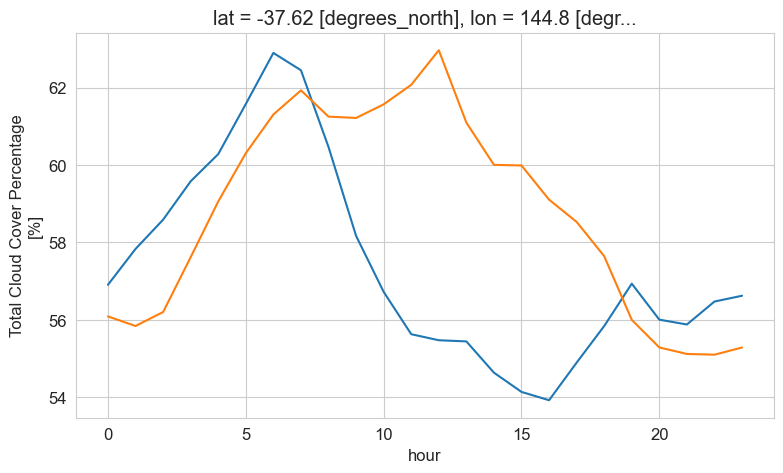

In [6]:
da_model_fut.groupby("time.hour").mean().plot() # blue
da_model_hist.groupby("time.hour").mean().plot() # orange

In [7]:
# Bin edges: left edges are 0, 12.5, 25, ... , 100, and include a final edge 112.5 to capture 100.
bins = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100., 112.5])

# Helper: assign to left bin edge (vectorized)
def assign_to_left_bin(x, bins):
    """
    Vectorized function used with xr.apply_ufunc.
    For each scalar x, returns the left-edge bin value where x belongs.
    Uses right=False so intervals are [left, right).
    """
    idx = np.digitize(x, bins, right=False) - 1   # 0-based bin index
    idx = np.clip(idx, 0, len(bins)-2)            # safety (ensure indices 0..8)
    return bins[idx]


def assign_to_bin_center(x, bins):
    """
    Assign each value x to the CENTER of the bin it falls into.
    """
    # Find 0-based bin index (same logic as before)
    idx = np.digitize(x, bins, right=False) - 1
    idx = np.clip(idx, 0, len(bins) - 2)
    centers = (bins[:-1] + bins[1:]) / 2.0
    return centers[idx]


In [8]:
obs_raw = ds_nathers_local['clt'].copy()
mod_raw = ds_barra_local['clt'].copy()

# count spurious values outside 0..100
n_obs_below = (obs_raw < 0).sum().item()
n_obs_above = (obs_raw > 100).sum().item()
n_mod_below = (mod_raw < 0).sum().item()
n_mod_above = (mod_raw > 100).sum().item()

print(f"NatHERS: {n_obs_below} values <0, {n_obs_above} values >100")
print(f"BARRA : {n_mod_below} values <0, {n_mod_above} values >100")

# clip values to [0, 100]
obs = obs_raw.clip(min=0, max=100)
mod = mod_raw.clip(min=0, max=100)

# align timestamps (inner join) so both arrays share same time index
obs, mod = xr.align(obs, mod, join="inner")
print("Aligned lengths:", obs.sizes["time"])


NatHERS: 0 values <0, 0 values >100
BARRA : 0 values <0, 0 values >100
Aligned lengths: 219119


In [9]:
# For the model
barra_clt_binned = xr.apply_ufunc(
    assign_to_left_bin,
    mod,
    kwargs={"bins": bins},
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)
# mod_centered = xr.apply_ufunc(
#     assign_to_bin_center,
#     mod,
#     kwargs={"bins": bins},
#     vectorize=True,
#     dask="parallelized",
#     output_dtypes=[float],
# )

# For observations
nathers_clt_binned = xr.apply_ufunc(
    assign_to_left_bin,
    obs,
    kwargs={"bins": bins},
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

# Quick sanity output: unique values (should be left-edge set)
print("Unique obs binned values:", np.unique(nathers_clt_binned.values))
print("Unique mod binned values:", np.unique(barra_clt_binned.values))
# print("Unique mod_cntre binned values:", np.unique(mod_centered.values))

Unique obs binned values: [  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]
Unique mod binned values: [  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]


In [10]:
# integer bin indices (0 = 0%, 1 = 12.5% ... 8 = 100%)

def left_edge_to_index(da, bins):
    """
    Convert left-edge percent values into integer bin index 0..8.
    If da contains left-edge values (0,12.5,...), this finds the index.
    """
    # The left-edge value must match bins[:-1]
    left_edges = bins[:-1]
    # vectorized search: for each value, find where it equals left_edges
    arr = da.values
    # create mapping from value to index using a dict for speed
    edge_to_idx = {val: idx for idx, val in enumerate(left_edges)}
    # use vectorized approach with np.vectorize
    func = np.vectorize(lambda x: edge_to_idx.get(float(x), np.nan))
    idx_arr = func(arr)
    return xr.DataArray(idx_arr, coords=da.coords, dims=da.dims, name="bin_index")

obs_idx = left_edge_to_index(nathers_clt_binned, bins).astype(float)  # float for NaNs
mod_idx = left_edge_to_index(barra_clt_binned, bins).astype(float)

# quick check
print("obs_idx unique:", np.unique(obs_idx.values[~np.isnan(obs_idx.values)]))
print("mod_idx unique:", np.unique(mod_idx.values[~np.isnan(mod_idx.values)]))


obs_idx unique: [0. 1. 2. 3. 4. 5. 6. 7. 8.]
mod_idx unique: [0. 1. 2. 3. 4. 5. 6. 7. 8.]


In [11]:
# Build conditional PMFs with a sliding window
def build_conditional_pmf_sliding(obs_idx, mod_idx, window=1):
    """
    For each hour (0..23), pool data from hours in [h-window, ..., h+window]
    and compute empirical PMFs P(obs_bin | mod_bin) for mod_bin in 0..8.
    Returns dict keyed by (mod_bin, hour) -> pmf (length 9).
    """
    cond_pmf = {}
    hours = np.arange(24)

    # time hour arrays for selection
    obs_hours = obs_idx['time'].dt.hour
    mod_hours = mod_idx['time'].dt.hour

    for hour in hours:
        hours_to_use = [(hour + offset) % 24 for offset in range(-window, window + 1)]

        # subset arrays to those hours (pooling)
        obs_slice = obs_idx.where(obs_hours.isin(hours_to_use), drop=True)
        mod_slice = mod_idx.where(mod_hours.isin(hours_to_use), drop=True)

        # flatten
        obs_vals = obs_slice.values.ravel()
        mod_vals = mod_slice.values.ravel()

        # filter valid pairs
        mask = ~np.isnan(obs_vals) & ~np.isnan(mod_vals)
        obs_vals = obs_vals[mask].astype(int)
        mod_vals = mod_vals[mask].astype(int)

        # build conditional PMFs for each mod_bin (0..8)
        for m_bin in range(len(bins)-1):
            obs_given_mod = obs_vals[mod_vals == m_bin]
            if obs_given_mod.size == 0:
                pmf = np.zeros(len(bins)-1)
            else:
                counts = np.bincount(obs_given_mod, minlength=(len(bins)-1))
                pmf = counts / counts.sum()
            cond_pmf[(m_bin, hour)] = pmf

    return cond_pmf

# Build PMFs with a chosen window (try window=1 first)
window = 1
cond_pmf = build_conditional_pmf_sliding(obs_idx, mod_idx, window=window)
print("PMFs built for combinations:", len(cond_pmf))
# inspect an example
print("Example PMF for (mod_bin=4, hour=12):", cond_pmf.get((4,12)))


PMFs built for combinations: 216
Example PMF for (mod_bin=4, hour=12): [0.02999492 0.1270971  0.07981698 0.10879512 0.08795119 0.1931876
 0.15149975 0.17742755 0.04422979]


In [12]:
# Stochastic mapping using averaged window PMFs

def map_mod_to_obs_stochastic_sliding(mod_idx_da, cond_pmf, bins, seed=None, window=1):
    """
    For each model time step, find model bin m and hour h.
    Gather PMFs (m, h') for h' in h±window and average them (if present).
    Sample an obs_bin from the averaged PMF and return left-edge percent.
    """
    rng = np.random.default_rng(seed)
    mod_vals = mod_idx_da.values
    times = pd.DatetimeIndex(mod_idx_da['time'].values)
    mapped_idx = np.full(mod_vals.shape, np.nan)

    for i, (mval, t) in enumerate(zip(mod_vals, times)):
        if np.isnan(mval):
            continue
        mbin = int(mval)
        hour = t.hour
        hours_to_use = [(hour + o) % 24 for o in range(-window, window+1)]

        # collect PMFs for this mbin across the window hours (if they exist)
        pmf_list = []
        for h in hours_to_use:
            pmf = cond_pmf.get((mbin, h))
            if pmf is not None:
                pmf_list.append(pmf)
        if len(pmf_list) == 0:
            mapped_idx[i] = mbin
            continue

        avg_pmf = np.mean(pmf_list, axis=0)
        # normalize (safety)
        if avg_pmf.sum() == 0:
            mapped_idx[i] = mbin
            continue
        avg_pmf = avg_pmf / avg_pmf.sum()
        sampled = rng.choice(np.arange(len(bins)-1), p=avg_pmf)
        mapped_idx[i] = sampled

    # convert bin indices back to left-edge percent values
    mapped_left = bins[mapped_idx.astype(int)]
    return xr.DataArray(mapped_left, coords=mod_idx_da.coords, dims=mod_idx_da.dims, name="clt_adj")

# Run mapping with chosen window and seed
seed = 42
mod_adj = map_mod_to_obs_stochastic_sliding(mod_idx, cond_pmf, bins, seed=seed, window=window)

# quick peek
print("First 10 adjusted values:", mod_adj.values[:10])


First 10 adjusted values: [87.5 12.5 50.  25.   0.  87.5 37.5 50.  12.5 25. ]


In [13]:
# integer codes (0..8) for metrics
def left_edge_values_to_codes(da_left, bins):
    """
    Convert DataArray of left-edge bin values (e.g., 0,12.5,...) to integer codes 0..8.
    """
    left_edges = bins[:-1]
    edge_to_idx = {val: idx for idx, val in enumerate(left_edges)}
    arr = da_left.values
    func = np.vectorize(lambda x: edge_to_idx.get(float(x), np.nan))
    idx_arr = func(arr)
    return xr.DataArray(idx_arr, coords=da_left.coords, dims=da_left.dims)

obs_codes = left_edge_values_to_codes(nathers_clt_binned, bins).astype(int).values
mod_codes = left_edge_values_to_codes(barra_clt_binned, bins).astype(int).values
adj_codes = left_edge_values_to_codes(mod_adj, bins).astype(int).values

# ensure same length and no NaNs (align earlier)
n = len(obs_codes)
print("Sample sizes:", n)


Sample sizes: 219119


=== Distribution Metrics ===
KL divergence (raw): 0.2631, (adj): 0.0000
Wasserstein distance (raw): 0.5724, (adj): 0.0074
Chi-square statistic (raw): 419209.9, (adj): 13.9


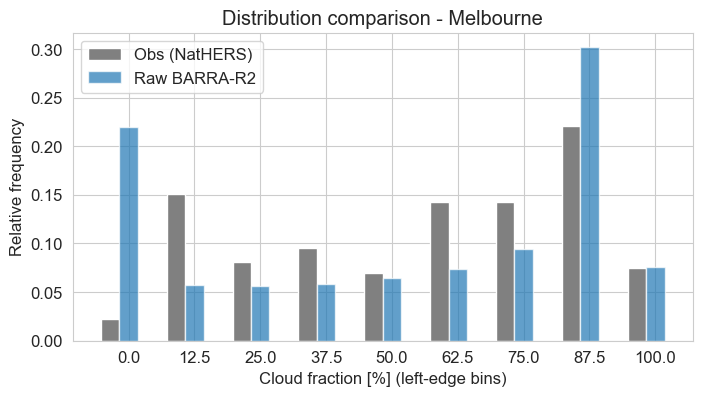

In [14]:
# distribution metrics and plot

# frequencies (ensure all bins present using reindex)
obs_freq = pd.Series(obs_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)
mod_freq = pd.Series(mod_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)
adj_freq = pd.Series(adj_codes).value_counts(normalize=True).sort_index().reindex(range(len(bins)-1), fill_value=0)

# KL divergence (obs vs model/adj)
kl_raw = entropy(obs_freq + 1e-12, mod_freq + 1e-12)  # tiny epsilon for safety
kl_adj = entropy(obs_freq + 1e-12, adj_freq + 1e-12)

# Wasserstein distance (treating codes as ordered support)
wd_raw = wasserstein_distance(obs_codes, mod_codes)
wd_adj = wasserstein_distance(obs_codes, adj_codes)

# Chi-square (use counts not normalized)
counts_obs = pd.Series(obs_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)
counts_mod = pd.Series(mod_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)
counts_adj = pd.Series(adj_codes).value_counts().sort_index().reindex(range(len(bins)-1), fill_value=0)

chi2_raw = chisquare(f_obs=counts_mod.values, f_exp=counts_obs.values)
chi2_adj = chisquare(f_obs=counts_adj.values, f_exp=counts_obs.values)

print("=== Distribution Metrics ===")
print(f"KL divergence (raw): {kl_raw:.4f}, (adj): {kl_adj:.4f}")
print(f"Wasserstein distance (raw): {wd_raw:.4f}, (adj): {wd_adj:.4f}")
print(f"Chi-square statistic (raw): {chi2_raw.statistic:.1f}, (adj): {chi2_adj.statistic:.1f}")

# Plot
x = bins[:-1]   # left-edge percent values for x-axis
width = 3.5
plt.figure(figsize=(8,4))
plt.bar(x - width, obs_freq.values, width=width, label="Obs (NatHERS)", align="center", color="gray")
plt.bar(x, mod_freq.values, width=width, label="Raw BARRA-R2", align="center", alpha=0.7)
plt.bar(x + width, adj_freq.values, width=width, label="Adj. BARRA-R2", align="center", alpha=0.7)
plt.xticks(x)
plt.xlabel("Cloud fraction [%] (left-edge bins)")
plt.ylabel("Relative frequency")
plt.title(f"Distribution comparison - {loc}")
plt.legend()
plt.show()


Accuracy (raw): 0.190
Accuracy (adj): 0.179


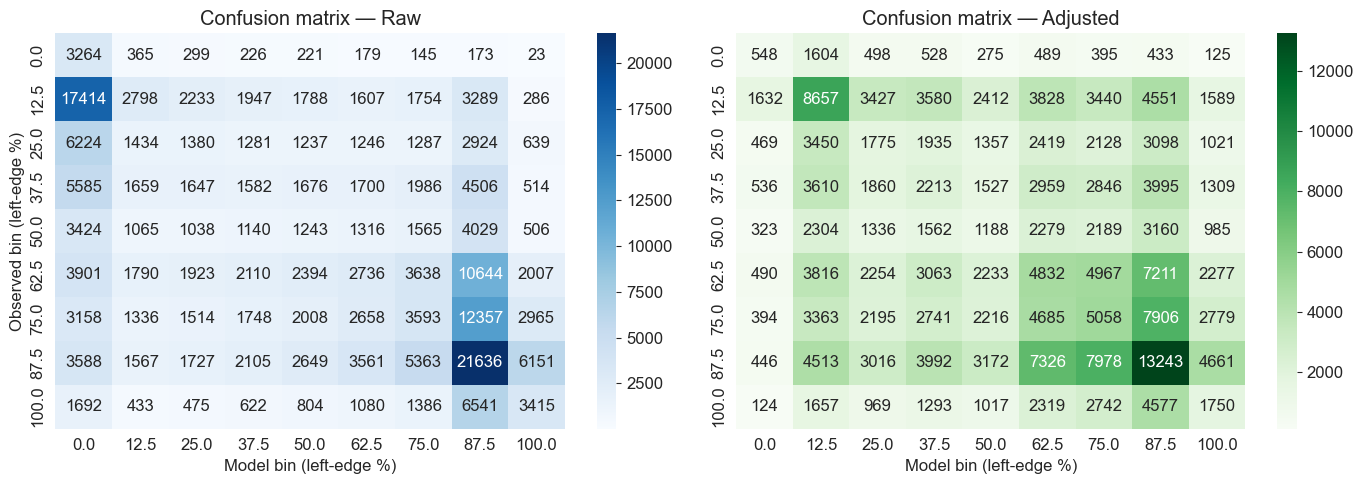

In [17]:
# Cell 10 — confusion matrices & accuracy

labels = list(range(len(bins)-1))  # 0..8

cm_raw = confusion_matrix(obs_codes, mod_codes, labels=labels)
cm_adj = confusion_matrix(obs_codes, adj_codes, labels=labels)

acc_raw = accuracy_score(obs_codes, mod_codes)
acc_adj = accuracy_score(obs_codes, adj_codes)

print(f"Accuracy (raw): {acc_raw:.3f}")
print(f"Accuracy (adj): {acc_adj:.3f}")

# Plot confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(14,5))
sns.heatmap(cm_raw, annot=True, fmt='d', ax=axs[0], cmap='Blues', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[0].set_title("Confusion matrix — Raw")
axs[0].set_xlabel("Model bin (left-edge %)")
axs[0].set_ylabel("Observed bin (left-edge %)")
sns.heatmap(cm_adj, annot=True, fmt='d', ax=axs[1], cmap='Greens', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[1].set_title("Confusion matrix — Adjusted")
axs[1].set_xlabel("Model bin (left-edge %)")
plt.tight_layout()
plt.show()


Mean persistence (obs/raw/adj): 0.50860877490744 0.4026906853839099 0.14457095574781179


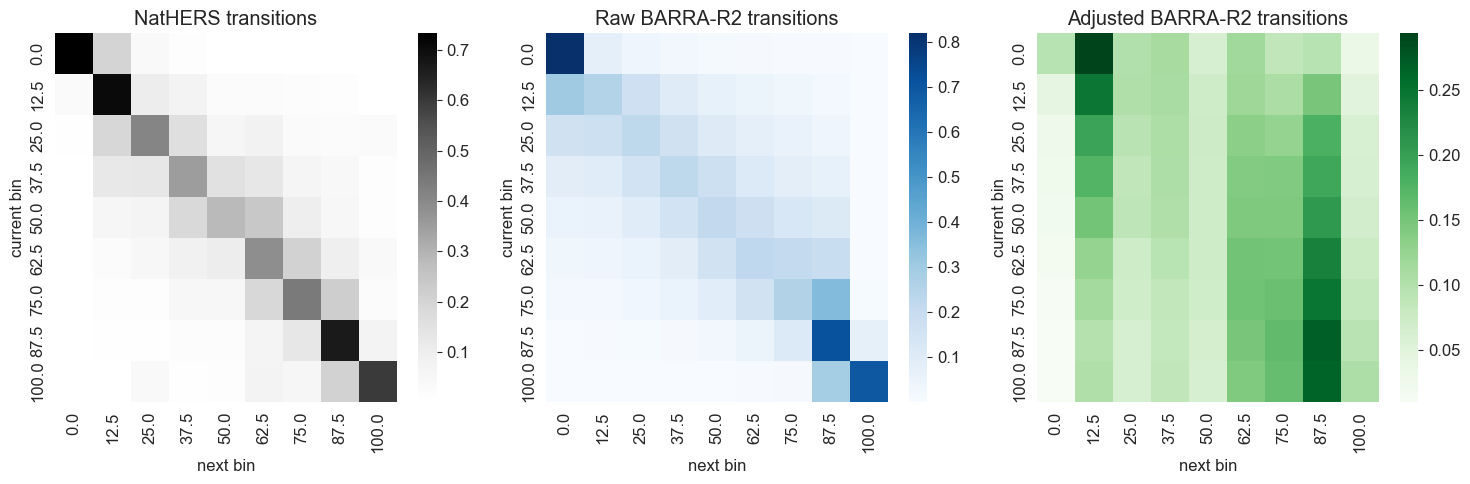

In [18]:
# Cell 11 — transitions

def transition_matrix(codes, n_classes):
    """Return row-normalized transition matrix P(next | current)."""
    mat = np.zeros((n_classes, n_classes))
    for a, b in zip(codes[:-1], codes[1:]):
        mat[a, b] += 1
    # avoid division by zero: normalize rows when row sum > 0
    row_sums = mat.sum(axis=1, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        mat_norm = np.divide(mat, row_sums, where=(row_sums!=0))
    mat_norm = np.nan_to_num(mat_norm)
    return mat_norm

n_classes = len(bins)-1
tm_obs = transition_matrix(obs_codes, n_classes)
tm_raw = transition_matrix(mod_codes, n_classes)
tm_adj = transition_matrix(adj_codes, n_classes)

persistence_obs = np.mean(np.diag(tm_obs))
persistence_raw = np.mean(np.diag(tm_raw))
persistence_adj = np.mean(np.diag(tm_adj))

print("Mean persistence (obs/raw/adj):", persistence_obs, persistence_raw, persistence_adj)

# Plot matrices
fig, axs = plt.subplots(1,3, figsize=(15,5))
sns.heatmap(tm_obs, ax=axs[0], cmap='Greys', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[0].set_title("NatHERS transitions")
sns.heatmap(tm_raw, ax=axs[1], cmap='Blues', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[1].set_title("Raw BARRA-R2 transitions")
sns.heatmap(tm_adj, ax=axs[2], cmap='Greens', xticklabels=bins[:-1], yticklabels=bins[:-1])
axs[2].set_title("Adjusted BARRA-R2 transitions")
for ax in axs:
    ax.set_xlabel("next bin")
    ax.set_ylabel("current bin")
plt.tight_layout()
plt.show()


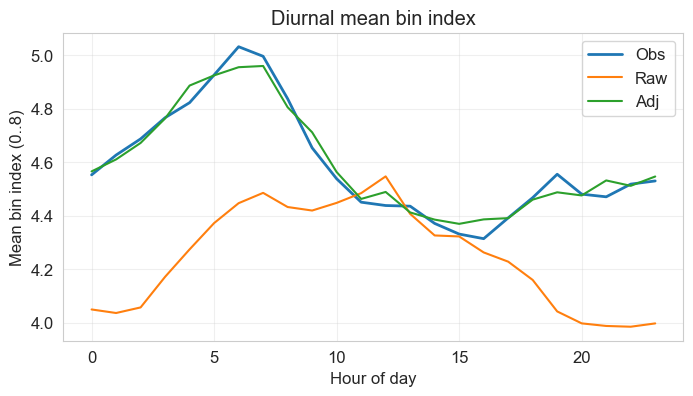

Hourly mean correlation: raw=0.239, adj=0.984


In [19]:
# Cell 12 — diurnal profiles

times = pd.DatetimeIndex(obs_idx['time'].values)
obs_hourly = pd.Series(obs_codes, index=times).groupby(times.hour).mean()
mod_hourly = pd.Series(mod_codes, index=times).groupby(times.hour).mean()
adj_hourly = pd.Series(adj_codes, index=times).groupby(times.hour).mean()

plt.figure(figsize=(8,4))
plt.plot(obs_hourly.index, obs_hourly.values, label="Obs", lw=2)
plt.plot(mod_hourly.index, mod_hourly.values, label="Raw", lw=1.5)
plt.plot(adj_hourly.index, adj_hourly.values, label="Adj", lw=1.5)
plt.xlabel("Hour of day")
plt.ylabel("Mean bin index (0..8)")
plt.title("Diurnal mean bin index")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Hourly correlation with observations
corr_raw = np.corrcoef(obs_hourly.values, mod_hourly.values)[0,1]
corr_adj = np.corrcoef(obs_hourly.values, adj_hourly.values)[0,1]
print(f"Hourly mean correlation: raw={corr_raw:.3f}, adj={corr_adj:.3f}")


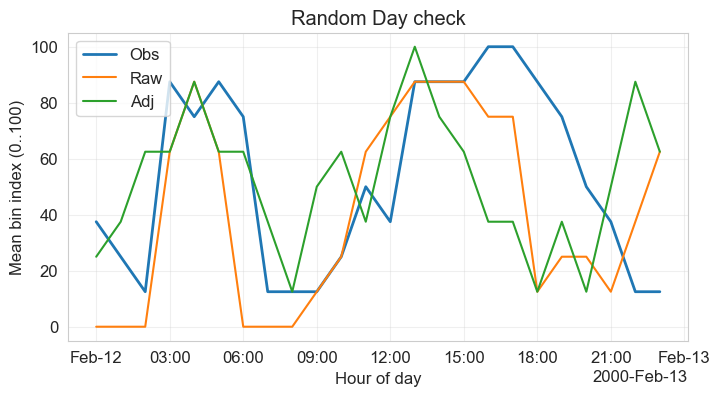

In [20]:
#— random day
day = "2000-02-12"
obs_hourly = nathers_clt_binned.sel(time=day)
mod_hourly = barra_clt_binned.sel(time=day)
adj_hourly = mod_adj.sel(time=day)

plt.figure(figsize=(8,4))
obs_hourly.plot(label="Obs", lw=2)
mod_hourly.plot(label="Raw", lw=1.5)
adj_hourly.plot(label="Adj", lw=1.5)
plt.xlabel("Hour of day")
plt.ylabel("Mean bin index (0..100)")
plt.title("Random Day check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [85]:
# Seed sensitivity (quick test)

def run_with_seed(seed, mod_idx_da, cond_pmf, bins, window=1):
    adj = map_mod_to_obs_stochastic_sliding(mod_idx_da, cond_pmf, bins, seed=seed, window=window)
    adj_codes_local = left_edge_values_to_codes(adj, bins).astype(int).values
    acc = accuracy_score(obs_codes, adj_codes_local)
    return acc

seeds = [1, 7, 42, 100, 999]
results = [(s, run_with_seed(s, mod_idx, cond_pmf, bins, window=window)) for s in seeds]
pd.DataFrame(results, columns=["seed", "accuracy"])


,seed,accuracy
0,1,0.178647
1,7,0.180651
2,42,0.179190
3,100,0.179496
4,999,0.178958
